# 第7章: 機械学習

本章では、[Stanford Sentiment Treebank (SST)](https://nlp.stanford.edu/sentiment/) データセットを用い、評判分析器（ポジネガ分類器）を構築する。ここでは処理を簡略化するため、[General Language Understanding Evaluation (GLUE)](https://gluebenchmark.com/) ベンチマークで配布されているSSTデータセットを用いる。


# Chương 7: Machine Learning

Trong chương này, bạn sẽ xây dựng một bộ phân loại cảm xúc (sentiment classifier) để xác định một câu là:

- Positive (tích cực)
- Negative (tiêu cực)

Sử dụng bộ dữ liệu:

Stanford Sentiment Treebank

Để đơn giản hóa, đề bài sử dụng phiên bản:

SST-2

được phát hành trong benchmark:

GLUE

In [1]:
!wget -q https://dl.fbaipublicfiles.com/glue/data/SST-2.zip
!unzip -o SST-2.zip

Archive:  SST-2.zip
   creating: SST-2/
  inflating: SST-2/dev.tsv           
   creating: SST-2/original/
  inflating: SST-2/original/README.txt  
  inflating: SST-2/original/SOStr.txt  
  inflating: SST-2/original/STree.txt  
  inflating: SST-2/original/datasetSentences.txt  
  inflating: SST-2/original/datasetSplit.txt  
  inflating: SST-2/original/dictionary.txt  
  inflating: SST-2/original/original_rt_snippets.txt  
  inflating: SST-2/original/sentiment_labels.txt  
  inflating: SST-2/test.tsv          
  inflating: SST-2/train.tsv         


In [2]:
import pandas as pd

train_df = pd.read_csv(
    "SST-2/train.tsv",
    sep="\t"
)

dev_df = pd.read_csv(
    "SST-2/dev.tsv",
    sep="\t"
)

In [3]:
train_df.head()

,sentence,label
0,hide new secretions from the parental units,0
1,"contains no wit , only labored gags",0
2,that loves its characters and communicates som...,1
3,remains utterly satisfied to remain the same t...,0
4,on the worst revenge-of-the-nerds clichés the ...,0


## 60. データの入手・整形

GLUEのウェブサイトから[SST-2](https://dl.fbaipublicfiles.com/glue/data/SST-2.zip)データセットを取得せよ。学習データ（`train.tsv`）と検証データ（`dev.tsv`）のぞれぞれについて、ポジティブ (1) とネガティブ (0) の事例数をカウントせよ。

## 60. Thu thập và xử lý dữ liệu

Hãy tải bộ dữ liệu SST-2 từ GLUE.

Đối với:

- train.tsv
- dev.tsv

hãy đếm số lượng mẫu:

- Positive (1)
- Negative (0)

In [4]:
print("Train dataset")
print(train_df["label"].value_counts())

print("\nDev dataset")
print(dev_df["label"].value_counts())

Train dataset
label
1    37569
0    29780
Name: count, dtype: int64

Dev dataset
label
1    444
0    428
Name: count, dtype: int64


## 61. 特徴ベクトル

Bag of Words (BoW) に基づき、学習データ（`train.tsv`）および検証データ（`dev.tsv`）のテキストを特徴ベクトルに変換したい。ここで、ある事例のテキストの特徴ベクトルは、テキスト中に含まれる単語（スペース区切りのトークン）の出現頻度で構成する。例えば、"too loud , too goofy"というテキストに対応する特徴ベクトルは、以下のような辞書オブジェクトで表現される。

```python
{'too': 2, 'loud': 1, ',': 1, 'goofy': 1}
```

各事例はテキスト、特徴ベクトル、ラベルを格納した辞書オブジェクトでまとめておく。例えば、先ほどの"too loud , too goofy"に対してラベル"0"（ネガティブ）が付与された事例は、以下のオブジェクトで表現される。

```python
{'text': 'too loud , too goofy', 'label': '0', 'feature': {'too': 2, 'loud': 1, ',': 1, 'goofy': 1}}
```

学習データと検証データの各事例を上記のような辞書オブジェクトに変換したうえで、学習データと検証データのそれぞれを、辞書オブジェクトのリストとして表現せよ。さらに、学習データの最初の事例について、正しく特徴ベクトルに変換できたか、目視で確認せよ。


## 61. Vector đặc trưng

Hãy chuyển văn bản thành vector đặc trưng bằng phương pháp:

Bag of Words (BoW)

Vector đặc trưng được tạo từ:

- số lần xuất hiện của từng từ trong văn bản.

Ví dụ:

- too loud , too goofy

được biểu diễn thành:
```
{
    'too': 2,
    'loud': 1,
    ',': 1,
    'goofy': 1
}
```
Mỗi mẫu dữ liệu được biểu diễn bằng một dictionary:
```
{
    'text': 'too loud , too goofy',
    'label': '0',
    'feature': {
        'too': 2,
        'loud': 1,
        ',': 1,
        'goofy': 1
    }
}
```
Hãy:

- Chuyển toàn bộ train.tsv thành danh sách các dictionary.
- Chuyển toàn bộ dev.tsv thành danh sách các dictionary.
- Kiểm tra thủ công mẫu đầu tiên của tập train để xác nhận vector đặc trưng được tạo đúng.

In [5]:
# test

from collections import Counter

sentence = "too loud , too goofy"

feature = dict(Counter(sentence.split()))

print(feature)

{'too': 2, 'loud': 1, ',': 1, 'goofy': 1}


In [6]:
row = train_df.iloc[0]

sample = {
    "text": row["sentence"],
    "label": row["label"],
    "feature": dict(Counter(row["sentence"].split()))
}

print(sample)

{'text': 'hide new secretions from the parental units ', 'label': np.int64(0), 'feature': {'hide': 1, 'new': 1, 'secretions': 1, 'from': 1, 'the': 1, 'parental': 1, 'units': 1}}


In [7]:
# train

from collections import Counter

train_data = []

for _, row in train_df.iterrows():
    train_data.append({
        #"text": row["sentence"],
        "text": row["sentence"].strip(),
        "label": row["label"],
        "feature": dict(Counter(row["sentence"].split()))
    })

print(train_data[0])

{'text': 'hide new secretions from the parental units', 'label': 0, 'feature': {'hide': 1, 'new': 1, 'secretions': 1, 'from': 1, 'the': 1, 'parental': 1, 'units': 1}}


In [8]:
# dev

from collections import Counter

dev_data = []

for _, row in dev_df.iterrows():
    dev_data.append({
        #"text": row["sentence"],
        "text": row["sentence"].strip(),
        "label": row["label"],
        "feature": dict(Counter(row["sentence"].split()))
    })

print(dev_data[0])

{'text': "it 's a charming and often affecting journey .", 'label': 1, 'feature': {'it': 1, "'s": 1, 'a': 1, 'charming': 1, 'and': 1, 'often': 1, 'affecting': 1, 'journey': 1, '.': 1}}


## 62. 学習

61で構築した学習データの特徴ベクトルを用いて、ロジスティック回帰モデルを学習せよ。

## 62. Huấn luyện

Sử dụng các vector đặc trưng ở bài 61 để huấn luyện:

Logistic Regression

In [9]:
# vocabulary set

vocab = set()

for sample in train_data:
    vocab.update(sample["feature"].keys())

vocab = sorted(vocab)

print(vocab)

['!', '!?', '#', '$', '&', "'", "''", "'30s", "'40s", "'50s", "'53", "'60s", "'70s", "'80s", "'90s", "'d", "'em", "'ll", "'m", "'n", "'n'", "'re", "'s", "'til", "'ve", '(', ')', '*', '***', '****', '+', ',', '-', '--', '.', '...', '/', '1', '1.8', '1/2', '10', '10,000', '10-course', '10-year', '10-year-old', '100', '100-minute', '101', '103-minute', '105', '10th', '10th-grade', '11', '110', '112-minute', '12-year-old', '120', '127', '129-minute', '12th', '13', '13th', '14-year-old', '140', '146', '15', '15-year', '15th', '163', '168-minute', '170', '1790', '18', '18-year-old', '1899', '19', '1920', '1930s', '1933', '1937', '1938', '1940s', '1950', '1950s', '1952', '1957', '1958', '1959', '1960', '1960s', '1962', '1970', '1970s', '1972', '1973', '1975', '1979', '1980', '1980s', '1984', '1986', '1987', '1989', '1993', '1994', '1995', '1997', '1998', '1999', '19th', '19th-century', '2', '2,500', '2-day', '2/3', '20', '20-car', '2000', '2001', '2002', '20th', '21/2', '21st', '22', '22-year

In [10]:
word2idx = {word: idx for idx, word in enumerate(vocab)}

print(word2idx)

{'!': 0, '!?': 1, '#': 2, '$': 3, '&': 4, "'": 5, "''": 6, "'30s": 7, "'40s": 8, "'50s": 9, "'53": 10, "'60s": 11, "'70s": 12, "'80s": 13, "'90s": 14, "'d": 15, "'em": 16, "'ll": 17, "'m": 18, "'n": 19, "'n'": 20, "'re": 21, "'s": 22, "'til": 23, "'ve": 24, '(': 25, ')': 26, '*': 27, '***': 28, '****': 29, '+': 30, ',': 31, '-': 32, '--': 33, '.': 34, '...': 35, '/': 36, '1': 37, '1.8': 38, '1/2': 39, '10': 40, '10,000': 41, '10-course': 42, '10-year': 43, '10-year-old': 44, '100': 45, '100-minute': 46, '101': 47, '103-minute': 48, '105': 49, '10th': 50, '10th-grade': 51, '11': 52, '110': 53, '112-minute': 54, '12-year-old': 55, '120': 56, '127': 57, '129-minute': 58, '12th': 59, '13': 60, '13th': 61, '14-year-old': 62, '140': 63, '146': 64, '15': 65, '15-year': 66, '15th': 67, '163': 68, '168-minute': 69, '170': 70, '1790': 71, '18': 72, '18-year-old': 73, '1899': 74, '19': 75, '1920': 76, '1930s': 77, '1933': 78, '1937': 79, '1938': 80, '1940s': 81, '1950': 82, '1950s': 83, '1952': 8

In [11]:
# sample -> vector

sample = train_data[0]

vector = [0] * len(vocab)

for word, count in sample["feature"].items():
        vector[word2idx[word]] = count

print(vector)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [12]:
print(sample["feature"])

for word, count in sample["feature"].items():
    print(word, word2idx[word], count)

print()

print(sum(x != 0 for x in vector))

for i, x in enumerate(vector):
    if x != 0:
        print(i, x)

{'hide': 1, 'new': 1, 'secretions': 1, 'from': 1, 'the': 1, 'parental': 1, 'units': 1}
hide 6138 1
new 8769 1
secretions 11389 1
from 5294 1
the 13131 1
parental 9369 1
units 13896 1

7
5294 1
6138 1
8769 1
9369 1
11389 1
13131 1
13896 1


In [13]:
# X_train - X_dev

X_train = []

for sample in train_data:
    vector = [0] * len(vocab)

    for word, count in sample["feature"].items():
        vector[word2idx[word]] = count

    X_train.append(vector)




print(X_train[0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [14]:
# y_train - y_dev

y_train = [sample["label"] for sample in train_data]

print(y_train[0])

0


In [29]:
# spicy parse CSR

from scipy.sparse import csr_matrix
import numpy as np

rows = []
cols = []
data = []

for i, sample in enumerate(train_data):
    for word, count in sample["feature"].items():
        rows.append(i)
        cols.append(word2idx[word])
        data.append(count)

X_train_csr = csr_matrix((data, (rows, cols)), shape=(len(train_data), len(vocab)))

y_train_csr = np.array([sample["label"] for sample in train_data])

In [33]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_csr, y_train_csr)

train_acc = model.score(X_train_csr, y_train_csr)

print(train_acc)

sample = X_train_csr[0]

print(model.predict(sample))
print(y_train_csr[0])

print(model.predict(X_train_csr[:5]))
print(y_train_csr[:5].tolist())

0.9420926814058115
[0]
0
[0 0 1 0 0]
[0, 0, 1, 0, 0]


In [15]:
# use CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train_cv = vectorizer.fit_transform(train_df["sentence"])
X_dev_cv = vectorizer.transform(dev_df["sentence"])

y_train_cv = train_df["label"]
y_dev_cv = dev_df["label"]

In [16]:
# use CountVectorizer
# logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_cv, y_train_cv)

LogisticRegression(max_iter=1000)

In [17]:
train_acc = model.score(X_train_cv, y_train_cv)

print(train_acc)

0.936791934549882


In [18]:
sample = X_train_cv[0]

print(model.predict(sample))
print(y_train_cv.iloc[0])

print(model.predict(X_train_cv[:5]))
print(y_train_cv[:5].tolist())

[0]
0
[0 0 1 0 0]
[0, 0, 1, 0, 0]


## 63. 予測

学習したロジスティック回帰モデルを用い、検証データの先頭の事例のラベル（ポジネガ）を予測せよ。また、予測されたラベルが検証データで付与されていたラベルと一致しているか、確認せよ。

## 63. Dự đoán

Sử dụng mô hình Logistic Regression đã huấn luyện:

- dự đoán nhãn của mẫu đầu tiên trong tập validation
- kiểm tra xem dự đoán có đúng với nhãn thật hay không

In [19]:
pred = model.predict(X_dev_cv[:1])

print("Predicted:", pred[0])
print("Actual:", y_dev_cv.iloc[0])
print("Correct:", pred[0] == y_dev_cv.iloc[0])

Predicted: 1
Actual: 1
Correct: True


## 64. 条件付き確率

学習したロジスティック回帰モデルを用い、検証データの先頭の事例を各ラベル（ポジネガ）に分類するときの条件付き確率を求めよ。

## 64. Xác suất có điều kiện

Đối với mẫu đầu tiên của tập validation:

hãy tính:

- xác suất thuộc lớp Positive
- xác suất thuộc lớp Negative

theo mô hình Logistic Regression.

In [20]:
prob = model.predict_proba(X_dev_cv[:1])

print(f"Negative: {prob[0][0]:.4f}")
print(f"Positive: {prob[0][1]:.4f}")

Negative: 0.0024
Positive: 0.9976


## 65. テキストのポジネガの予測

与えられたテキストのポジネガを予測するプログラムを実装せよ。例えば、テキストとして"the worst movie I 've ever seen"を与え、ロジスティック回帰モデルの予測結果を確認せよ。

## 65. Dự đoán cảm xúc cho văn bản mới

Hãy xây dựng chương trình nhận một câu bất kỳ rồi dự đoán:

- Positive
- Negative

Ví dụ:

```
the worst movie I've ever seen
```
và kiểm tra kết quả dự đoán.


In [21]:
sentence = ["the worst movie I've ever seen"]

vector = vectorizer.transform(sentence)

pred = model.predict(vector)

print(pred)

[0]


## 66. 混同行列の作成

学習したロジスティック回帰モデルの検証データにおける混同行列（confusion matrix）を求めよ。

## 66. Ma trận nhầm lẫn

Hãy tính:

Confusion Matrix

của mô hình trên tập validation.

In [22]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_dev_cv)

cm = confusion_matrix(y_dev_cv, y_pred)

print(cm)

[[332  96]
 [ 62 382]]


## 67. 精度の計測

学習したロジスティック回帰モデルの正解率、適合率、再現率、F1スコアを、学習データおよび検証データ上で計測せよ。

## 67. Đánh giá mô hình

Hãy tính các chỉ số sau trên:

tập train
tập validation

gồm:
- Accuracy
- Precision
- Recall
- F1 Score
	​


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_train_pred = model.predict(X_train_cv)
y_dev_pred = model.predict(X_dev_cv)

print("=== Train ===")
print(accuracy_score(y_train_cv, y_train_pred))
print(precision_score(y_train_cv, y_train_pred))
print(recall_score(y_train_cv, y_train_pred))
print(f1_score(y_train_cv, y_train_pred))

print()

print("=== Dev ===")
print(accuracy_score(y_dev_cv, y_dev_pred))
print(precision_score(y_dev_cv, y_dev_pred))
print(recall_score(y_dev_cv, y_dev_pred))
print(f1_score(y_dev_cv, y_dev_pred))


=== Train ===
0.936791934549882
0.9374179316140554
0.95011844872102
0.9437254616838738

=== Dev ===
0.8188073394495413
0.799163179916318
0.8603603603603603
0.8286334056399133


## 68. 特徴量の重みの確認

学習したロジスティック回帰モデルの中で、重みの高い特徴量トップ20と、重みの低い特徴量トップ20を確認せよ。

## 68. Kiểm tra trọng số đặc trưng

Sau khi huấn luyện Logistic Regression:

hãy tìm:

- 20 đặc trưng có trọng số lớn nhất
- 20 đặc trưng có trọng số nhỏ nhất

Ví dụ:
```
excellent
wonderful
amazing
```
có thể mang trọng số dương rất lớn.

Trong khi:
```
terrible
awful
boring
```
có thể mang trọng số âm rất lớn.

In [24]:
weights = model.coef_[0]

feature_names = vectorizer.get_feature_names_out()

word_weights = list(zip(feature_names, weights))

In [25]:
top_positive = sorted(word_weights, key=lambda x: x[1], reverse=True)[:20]
top_negative = sorted(word_weights, key=lambda x: x[1])[:20]

print("Top Positive words:")
for w, c in top_positive:
    print(w, c)

print("\nTop Negative words:")
for w, c in top_negative:
    print(w, c)

Top Positive words:
remarkable 3.457282279479735
refreshing 3.3883210286709673
powerful 3.3179981173194437
wonderful 3.1597196913051357
hilarious 3.1551225063856276
beautiful 3.0497881590614857
miracle 2.9801822818037746
enjoyable 2.96952085746357
terrific 2.9491700376606262
treat 2.921160515081644
appealing 2.908292376523816
vividly 2.856178054106574
charming 2.828025438272683
charmer 2.768270946677146
rely 2.7192831570150227
prose 2.7033524758239684
solid 2.6888760537921144
pleasant 2.675445960926161
intriguing 2.6717822486837752
anatomical 2.664165742036625

Top Negative words:
lacking -4.3988057528493325
worst -4.206079873677532
lacks -4.177701095972347
failure -3.74558480786003
devoid -3.6172958866453073
stupid -3.5721824307954555
mess -3.5488748937955816
bore -3.338056144833837
none -3.2094021891097273
waste -3.1777433708870375
lousy -3.099932230693195
pointless -3.0739002713614805
poorly -3.0658400234185232
squanders -3.0607878833161153
nowhere -3.058177767176223
lack -3.0383879

## 69. 正則化パラメータの変更

ロジスティック回帰モデルを学習するとき、正則化の係数（ハイパーパラメータ）を調整することで、学習時の適合度合いを制御できる。正則化の係数を変化させながらロジスティック回帰モデルを学習し、検証データ上の正解率を求めよ。実験の結果は、正則化パラメータを横軸、正解率を縦軸としたグラフにまとめよ。


## 69. Thay đổi hệ số regularization

Khi huấn luyện Logistic Regression:

hãy thay đổi hệ số regularization (hyperparameter).

Ví dụ:
```
0.001
0.01
0.1
1
10
100
```
Với mỗi giá trị:

- huấn luyện lại mô hình
- đo accuracy trên validation set

Sau đó vẽ đồ thị:

- trục X: regularization parameter
- trục Y: accuracy

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

C_values = [0.01, 0.1, 1, 10, 100]
train_acc = []
dev_acc = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000)

    model.fit(X_train_cv, y_train_cv)

    y_train_pred = model.predict(X_train_cv)
    y_dev_pred = model.predict(X_dev_cv)

    train_acc.append(accuracy_score(y_train_cv, y_train_pred))
    dev_acc.append(accuracy_score(y_dev_cv, y_dev_pred))

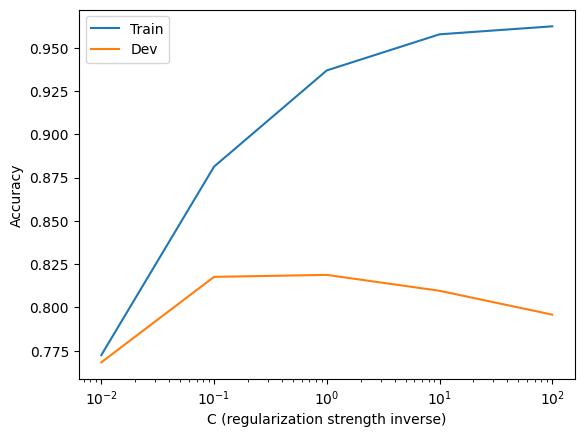

In [27]:
plt.plot(C_values, train_acc, label="Train")
plt.plot(C_values, dev_acc, label="Dev")

plt.xscale("log")
plt.xlabel("C (regularization strength inverse)")
plt.ylabel("Accuracy")
plt.legend()

plt.show()